In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import datetime as dt
import seaborn as sns
import numpy as np
from mlxtend.frequent_patterns import association_rules, apriori
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import math
import warnings
warnings.filterwarnings("ignore")

In [2]:
import platform
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic') 
else:   
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

In [3]:
df = pd.read_parquet("V2_merge.parquet")

## RFM + K-means

In [4]:
# RFM 지표 계산
df['t_dat'] = pd.to_datetime(df['t_dat'])
snapshot_date = df['t_dat'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    Recency=('t_dat', lambda x: (snapshot_date - x.max()).days), # 최근성
    Frequency=('t_dat', 'nunique'),                              # 방문 빈도
    Monetary=('price', 'sum')                                    # 총 구매 금액
).reset_index()

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 분석에 사용할 컬럼 추출 (RFM)
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# 데이터 스케일링 (단위를 일정하게 맞춤)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

In [6]:
# 최적의 k=4로 모델 확정
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 각 클러스터별 평균값 계산 (원본 데이터 기준)
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).rename(columns={'Recency': '최근성(일)', 'Frequency': '방문횟수(번)', 'Monetary': '총구매금액($)'})

# 클러스터별 고객 수 확인
cluster_profile['고객수'] = rfm['Cluster'].value_counts()

print(cluster_profile.sort_values('총구매금액($)', ascending=False))

             최근성(일)    방문횟수(번)     총구매금액($)     고객수
Cluster                                            
3         29.652834  42.032065  3189.160889   35303
1         56.792164  18.131518  1019.053345  210709
0        127.564804   4.141481   200.952103  708223
2        536.825626   1.791610    97.952927  406684


## LTV

In [7]:
# 1. RFM 결과 데이터가 있다면 로드 (없다면 rfm 변수를 사용)
# ltv_df가 rfm의 복사본이므로 rfm 데이터프레임이 먼저 있어야 합니다.
ltv_df = rfm.copy() 

# 2. LTV 모델을 위한 파생 변수 생성 (이전 단계 복습)
# Frequency에서 1을 빼 재구매 횟수로 변환
ltv_df['frequency_ltv'] = ltv_df['Frequency'] - 1 

# 1회 방문당 평균 구매 금액 계산
ltv_df['monetary_avg'] = ltv_df['Monetary'] / ltv_df['Frequency'] 

# 나이 결측치를 중앙값으로 채웠던 age_group 데이터와 병합되어 있어야 합니다.
# 만약 ltv_df에 age, FN, Active가 없다면 df_customers와 병합해야 합니다.
ltv_df = pd.merge(ltv_df, df[['customer_id', 'age', 'FN', 'Active']], on='customer_id', how='left')

## 시각화

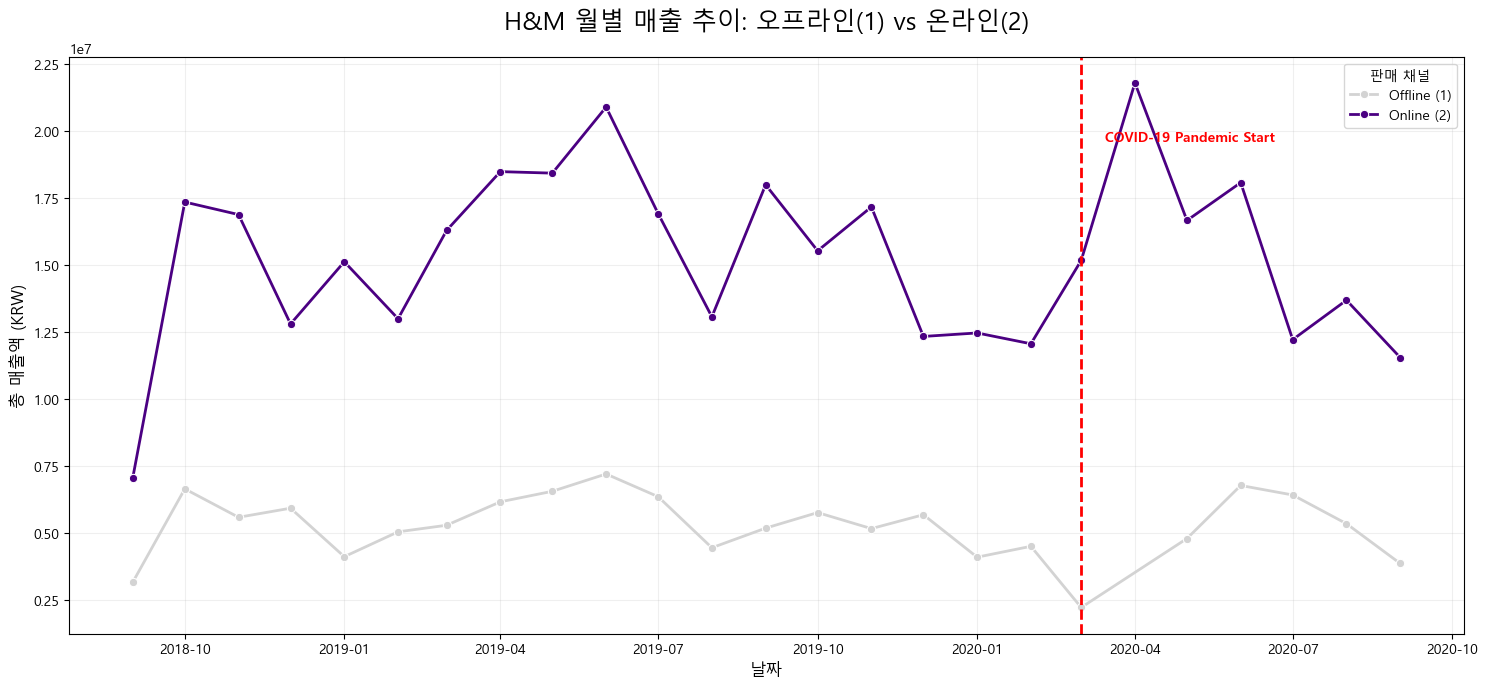

In [8]:
# 2. 월별 집계
df['month_year'] = df['t_dat'].dt.to_period('M')

# 3. 채널별 매출 및 고객수 집계
monthly_analysis = df.groupby(['month_year', 'sales_channel_id']).agg({
    'price': 'sum',
    'customer_id': 'nunique'
}).reset_index()

# 시각화를 위해 다시 datetime으로 변환
monthly_analysis['month_year'] = monthly_analysis['month_year'].dt.to_timestamp()

# --- 수정 포인트 시작 ---
# 4. 시각화 (색상 매핑을 명확히 지정)
plt.figure(figsize=(15, 7))

# 색상 딕셔너리 생성 (1: 오프라인, 2: 온라인)
# 오프라인은 흐린 색, 온라인은 강조되는 진한 색으로 설정하여 대조를 줍니다.
palette_colors = {1: "#D3D3D3", 2: "#4B0082"} 

# lineplot 실행 시 palette 파라미터를 사용하면 hue 값에 색상이 고정됩니다.
sns.lineplot(
    data=monthly_analysis, 
    x='month_year', 
    y='price', 
    hue='sales_channel_id', 
    palette=palette_colors, 
    marker='o',
    linewidth=2
)

# 5. 팬데믹 시작 시점 표시
plt.axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', linewidth=2)
plt.text(pd.Timestamp('2020-03-15'), monthly_analysis['price'].max() * 0.9, 
         'COVID-19 Pandemic Start', color='red', fontweight='bold')

# 6. 범례 및 라벨 정리 (수동 labels 대신 딕셔너리 매핑 권장)
# 자동으로 생성된 범례의 텍스트만 깔끔하게 바꿔줍니다.
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Offline (1)', 'Online (2)'], title='판매 채널', loc='upper right')

plt.title('H&M 월별 매출 추이: 오프라인(1) vs 온라인(2)', size=18, pad=20)
plt.xlabel('날짜', fontsize=12)
plt.ylabel('총 매출액 (KRW)', fontsize=12)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [9]:
# 온라인의 폭발적 성장 (Online 2): 온라인 매출은 팬데믹 직후 역대 최고치를 찍으며 급상승

# 오프라인의 침체 (Offline 1): 팬데믹 선포 직후 매출이 급격히 하락하여 역대 최저 수준을 기록

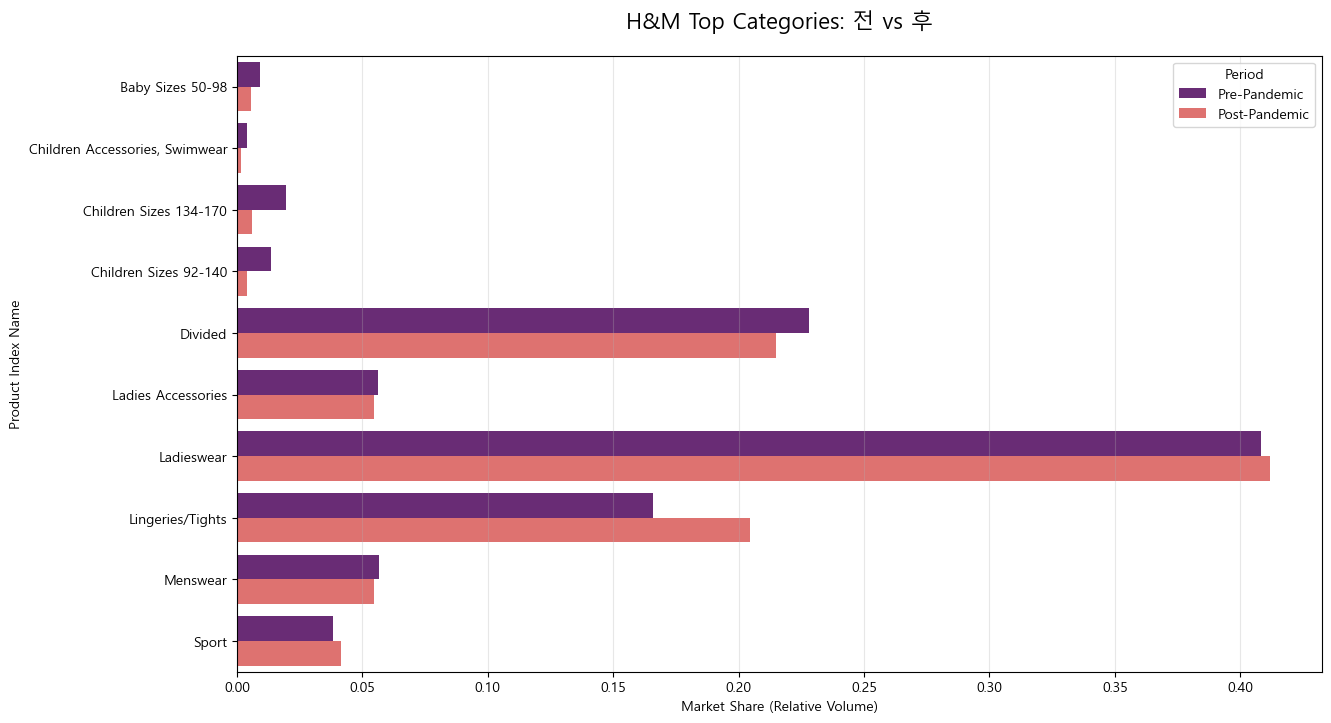

In [10]:
# 2. 기간 분리 (2020년 3월 기준)
# 2020년 3월 이후를 'Post-Pandemic'으로 설정하여 비즈니스 시의성을 보완합니다
pre_covid = df[df['t_dat'] < '2020-03-01']
post_covid = df[df['t_dat'] >= '2020-03-01']

# 3. 기간별 인기 상품군 집계 (판매량 기준)
pre_rank = pre_covid['index_name'].value_counts(normalize=True).head(10).reset_index()
pre_rank.columns = ['Category', 'Share']
pre_rank['Period'] = 'Pre-Pandemic'

post_rank = post_covid['index_name'].value_counts(normalize=True).head(10).reset_index()
post_rank.columns = ['Category', 'Share']
post_rank['Period'] = 'Post-Pandemic'

# 데이터 합치기
comparison_df = pd.concat([pre_rank, post_rank])

# 4. 시각화 (도표 비교)
plt.figure(figsize=(14, 8))
sns.barplot(data=comparison_df, y='Category', x='Share', hue='Period', palette='magma')

plt.title('H&M Top Categories: 전 vs 후', size=16, pad=20)
plt.xlabel('Market Share (Relative Volume)')
plt.ylabel('Product Index Name')
plt.grid(axis='x', alpha=0.3)
plt.show()

In [11]:
# Lingeries/Tights의 급증: 팬데믹 이후 점유율이 가장 눈에 띄게 상승 재택근무와 실내 거주 시간이 늘어나며 실용적이고 편안한 의류에 대한 수요 증가한 것으로 보임

# Ladieswear의 견고함: 여전히 가장 큰 비중을 차지하며 핵심 상품군으로서의 위치를 지키고 있음

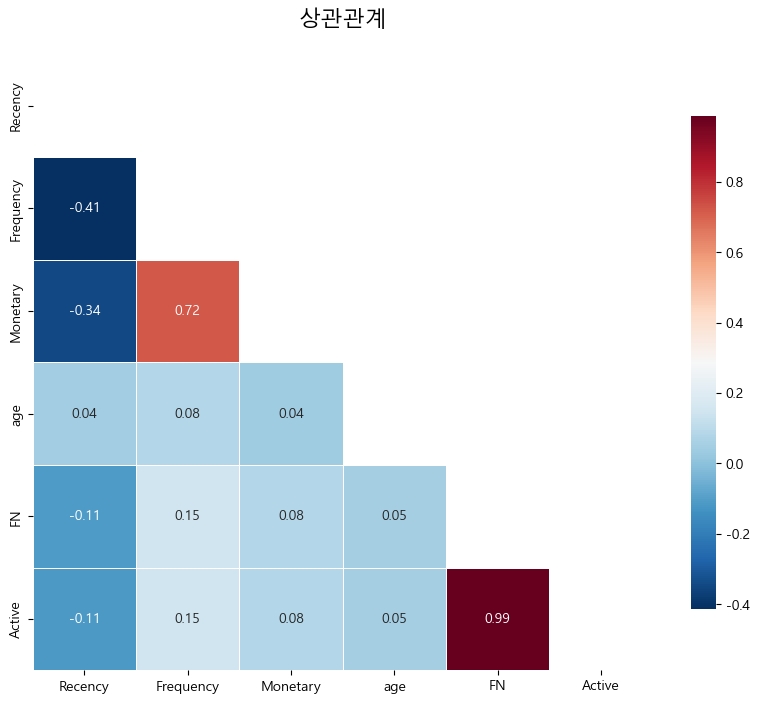

In [12]:
# 1. 상관관계 분석을 위한 핵심 컬럼 선정
# Recency, Frequency, Monetary: 현재 고객 가치
# age: 인구통계학적 특성
# FN, Active: 마케팅 활동성
corr_cols = ['Recency', 'Frequency', 'Monetary', 'age', 'FN', 'Active']

# 2. 상관계수 행렬 계산 (결측치는 제외하고 계산됨)
corr_matrix = ltv_df[corr_cols].corr()

# 3. 히트맵 시각화
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # 상삼각형 가리기 (중복 제거)

sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True,          # 숫자 표시
            fmt=".2f",           # 소수점 둘째자리까지
            cmap='RdBu_r',       # 붉은색(양), 푸른색(음) 컬러맵
            linewidths=0.5, 
            cbar_kws={"shrink": .8})

plt.title('상관관계', size=16, pad=20)
plt.show()

In [13]:
# Frequency & Monetary (0.72): 구매 빈도와 총 구매액 사이에 강한 양(+)의 상관관계가 있음. 즉, 자주 오는 고객이 결국 매출 기여도가 가장 높다는 정석적인 결과.

# Recency & Frequency (-0.41): 최근 구매일이 오래될수록(Recency 증가) 구매 빈도가 낮아지는 음(-)의 상관관계가 뚜렷. 고객이 잊기 전에 리마인드하는 것이 얼마나 중요한지 보여줌.

# FN & Active (0.99): 마케팅 수신 동의(FN)와 활성 상태(Active)는 거의 동일하게 움직임.

# 추가 인사이트: Age와 다른 지표 간의 상관관계(0.04~0.08)가 낮게 나타나는 점으로 보아, 특정 연령대보다는 구매 패턴(RFM) 자체를 기준으로 타겟팅하는 것이 더 정교한 접근임을 시사

In [ ]:
# 1. CSV 파일로 저장
# encoding='utf-8-sig'는 엑셀에서 열었을 때 한글(페르소나 명)이 깨지는 것을 방지합니다.
# index=False는 불필요한 인덱스 번호가 컬럼으로 추가되는 것을 막아줍니다.
# df.to_csv('final_hm_cluster.csv', index=False, encoding='utf-8-sig')

# print("✅ 메인 거래 데이터(df) CSV 저장 완료!")

✅ 메인 거래 데이터(df) CSV 저장 완료!
